# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Social Media Screen Time Mental Health Dataset](https://www.kaggle.com/datasets/uditjain13/social-media-screen-time-and-mental-health-2026/data)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('social_media_screentime_mental_health_2026.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,participant_id,age,gender,occupation,region,most_used_platform,platforms_used_count,daily_screen_hours,daily_notifications,night_time_use,...,life_satisfaction_1to10,loneliness_1to10,self_esteem_1to10,fomo_1to10,social_comparison_1to10,physical_activity_days_per_week,uses_screen_time_limits,attempted_digital_detox,seeks_mental_health_support,wellbeing_band
0,P300000,33,Male,Student,Latin America,TikTok,8,3.2,172,Never,...,9,6,4,6,8,4,No,No,No,At-risk
1,P300001,23,Female,Full-time employed,Oceania,Instagram,8,4.5,38,Often,...,7,5,8,5,8,4,No,"Yes, failed",Yes,At-risk
2,P300002,56,Female,Full-time employed,Africa,Instagram,1,5.3,74,Every night,...,8,7,3,2,3,5,No,No,No,Moderate
3,P300003,13,Male,Student,Europe,YouTube,4,3.4,49,Sometimes,...,10,6,6,1,5,4,No,"Yes, failed",Yes,Moderate
4,P300004,36,Female,Student,Asia,LinkedIn,5,5.8,227,Never,...,4,6,8,7,9,3,Yes,"Yes, succeeded",No,Moderate


## last Five row

In [4]:
df.tail()

,participant_id,age,gender,occupation,region,most_used_platform,platforms_used_count,daily_screen_hours,daily_notifications,night_time_use,...,life_satisfaction_1to10,loneliness_1to10,self_esteem_1to10,fomo_1to10,social_comparison_1to10,physical_activity_days_per_week,uses_screen_time_limits,attempted_digital_detox,seeks_mental_health_support,wellbeing_band
6995,P306995,30,Male,Part-time employed,Europe,Snapchat,4,3.6,74,Never,...,4,4,6,3,10,2,Yes,No,No,Good
6996,P306996,28,Male,Self-employed,North America,Facebook,3,5.0,104,Every night,...,8,1,7,6,7,1,No,"Yes, failed",No,Moderate
6997,P306997,26,Prefer not to say,Unemployed,Oceania,LinkedIn,3,1.2,25,Never,...,9,4,5,1,6,3,No,No,No,Good
6998,P306998,22,Female,Student,Europe,Snapchat,4,3.6,182,Sometimes,...,5,7,4,1,6,2,No,"Yes, failed",No,Good
6999,P306999,29,Male,Student,Asia,Facebook,1,5.8,14,Every night,...,5,7,4,9,6,3,No,No,Considering it,Moderate


## Shape of our dataset

In [5]:
df.shape

(7000, 25)

## List out all columns

In [6]:
df.columns

Index(['participant_id', 'age', 'gender', 'occupation', 'region',
       'most_used_platform', 'platforms_used_count', 'daily_screen_hours',
       'daily_notifications', 'night_time_use',
       'minutes_to_first_check_after_waking', 'primary_purpose',
       'avg_sleep_hours', 'anxiety_score_0to27', 'low_mood_score_0to27',
       'life_satisfaction_1to10', 'loneliness_1to10', 'self_esteem_1to10',
       'fomo_1to10', 'social_comparison_1to10',
       'physical_activity_days_per_week', 'uses_screen_time_limits',
       'attempted_digital_detox', 'seeks_mental_health_support',
       'wellbeing_band'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

participant_id                          object
age                                      int64
gender                                  object
occupation                              object
region                                  object
most_used_platform                      object
platforms_used_count                     int64
daily_screen_hours                     float64
daily_notifications                      int64
night_time_use                          object
minutes_to_first_check_after_waking      int64
primary_purpose                         object
avg_sleep_hours                        float64
anxiety_score_0to27                      int64
low_mood_score_0to27                     int64
life_satisfaction_1to10                  int64
loneliness_1to10                         int64
self_esteem_1to10                        int64
fomo_1to10                               int64
social_comparison_1to10                  int64
physical_activity_days_per_week          int64
uses_screen_t

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 25 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   participant_id                       7000 non-null   object 
 1   age                                  7000 non-null   int64  
 2   gender                               6930 non-null   object 
 3   occupation                           7000 non-null   object 
 4   region                               7000 non-null   object 
 5   most_used_platform                   7000 non-null   object 
 6   platforms_used_count                 7000 non-null   int64  
 7   daily_screen_hours                   7000 non-null   float64
 8   daily_notifications                  7000 non-null   int64  
 9   night_time_use                       7000 non-null   object 
 10  minutes_to_first_check_after_waking  7000 non-null   int64  
 11  primary_purpose               

## Check Null Value

In [9]:
df.isnull().sum()

participant_id                           0
age                                      0
gender                                  70
occupation                               0
region                                   0
most_used_platform                       0
platforms_used_count                     0
daily_screen_hours                       0
daily_notifications                      0
night_time_use                           0
minutes_to_first_check_after_waking      0
primary_purpose                          0
avg_sleep_hours                        105
anxiety_score_0to27                      0
low_mood_score_0to27                     0
life_satisfaction_1to10                  0
loneliness_1to10                         0
self_esteem_1to10                        0
fomo_1to10                               0
social_comparison_1to10                  0
physical_activity_days_per_week          0
uses_screen_time_limits                  0
attempted_digital_detox                  0
seeks_menta

# Drop Null Values

In [10]:
df.drop(columns=['gender', 'avg_sleep_hours'], inplace=True)

## Check Dupicate Value

In [11]:
df.duplicated().sum()

np.int64(0)

## Summary

In [12]:
df.describe()

,age,platforms_used_count,daily_screen_hours,daily_notifications,minutes_to_first_check_after_waking,anxiety_score_0to27,low_mood_score_0to27,life_satisfaction_1to10,loneliness_1to10,self_esteem_1to10,fomo_1to10,social_comparison_1to10,physical_activity_days_per_week
count,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000
mean,29.246571,3.494571,3.304971,61.528286,20.008286,11.378000,3.845714,6.955857,4.679286,6.006857,4.641857,5.323286,2.804143
std,9.569132,1.763637,1.881350,54.879070,13.976229,4.777726,3.534197,1.614486,2.094803,1.886767,2.157439,2.090788,1.288418
min,13.000000,1.000000,0.200000,5.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,22.000000,2.000000,1.900000,24.000000,10.000000,8.000000,0.000000,6.000000,3.000000,5.000000,3.000000,4.000000,2.000000
50%,29.000000,3.000000,3.000000,45.500000,17.000000,11.000000,3.000000,7.000000,5.000000,6.000000,5.000000,5.000000,3.000000
75%,36.000000,5.000000,4.300000,83.000000,27.000000,14.000000,6.000000,8.000000,6.000000,7.000000,6.000000,7.000000,4.000000
max,71.000000,8.000000,14.000000,400.000000,111.000000,27.000000,19.000000,10.000000,10.000000,10.000000,10.000000,10.000000,7.000000


# EDA

In [13]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

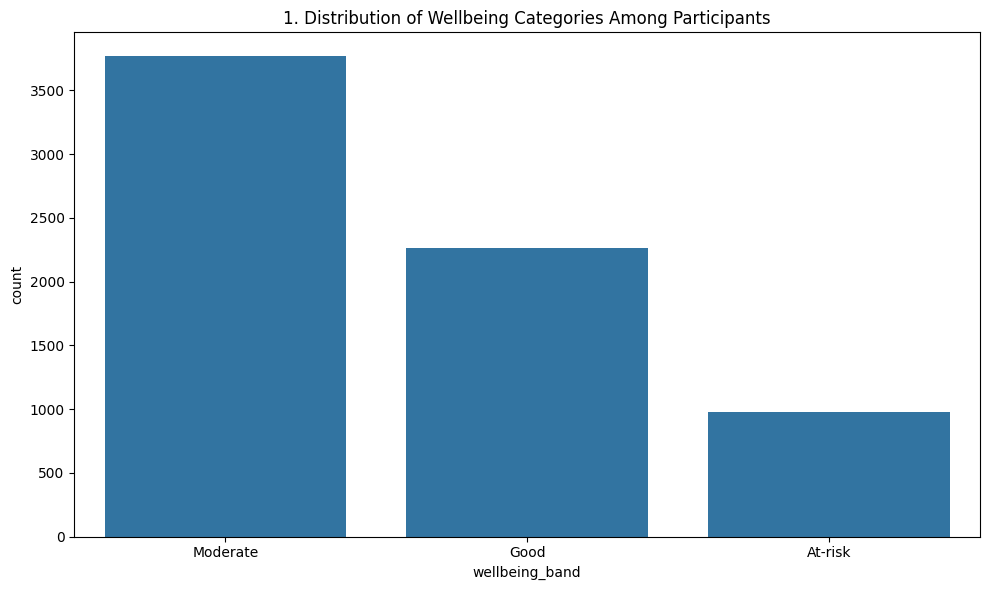

In [14]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='wellbeing_band', order=df['wellbeing_band'].value_counts().index)
plt.title(f'{plot_no}. Distribution of Wellbeing Categories Among Participants')
show_fig()
plot_no += 1

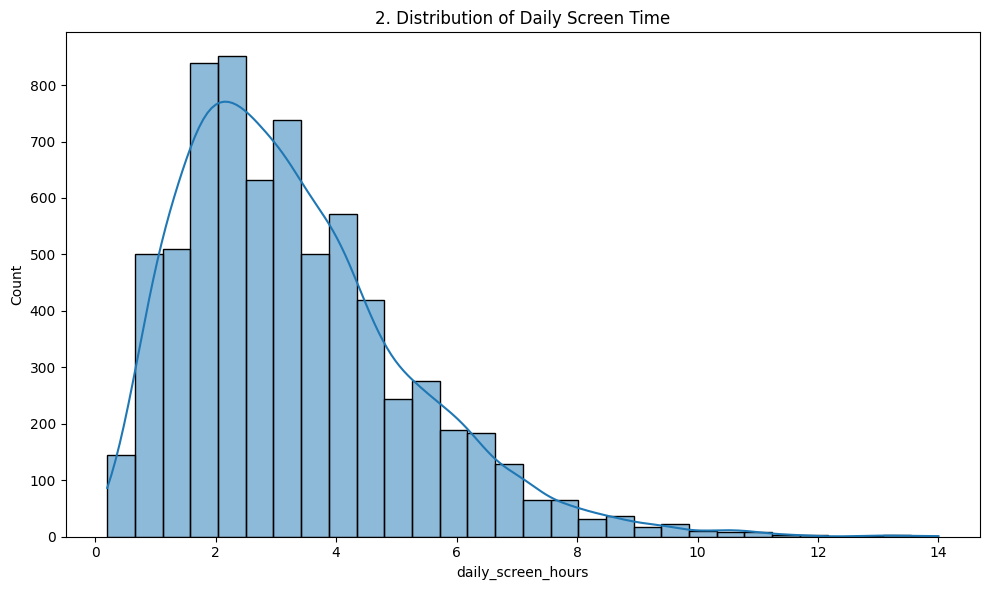

In [15]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['daily_screen_hours'], bins=30, kde=True)
plt.title(f'{plot_no}. Distribution of Daily Screen Time')
show_fig()
plot_no += 1

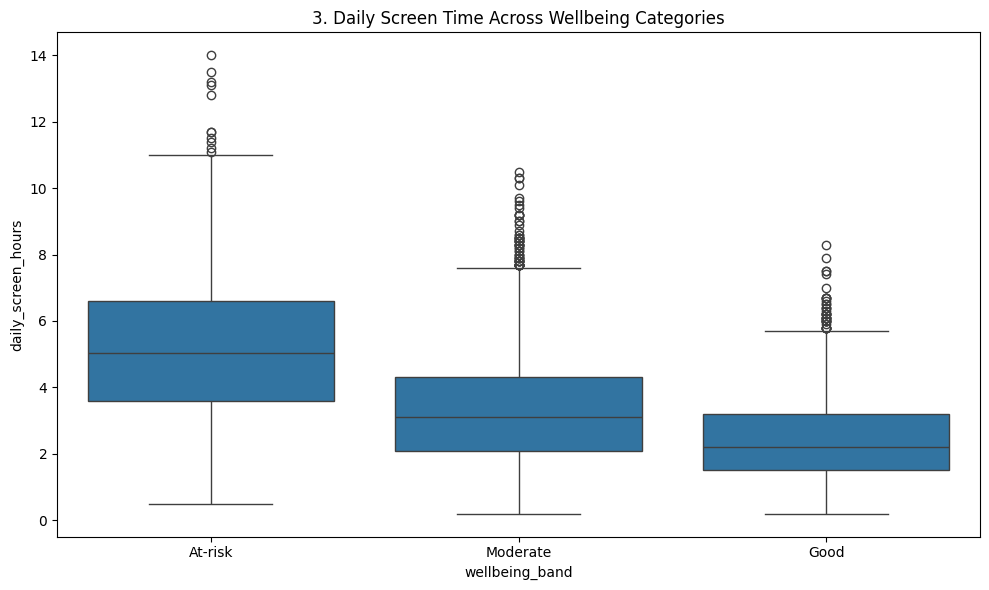

In [16]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='wellbeing_band', y='daily_screen_hours')
plt.title(f'{plot_no}. Daily Screen Time Across Wellbeing Categories')
show_fig()
plot_no += 1

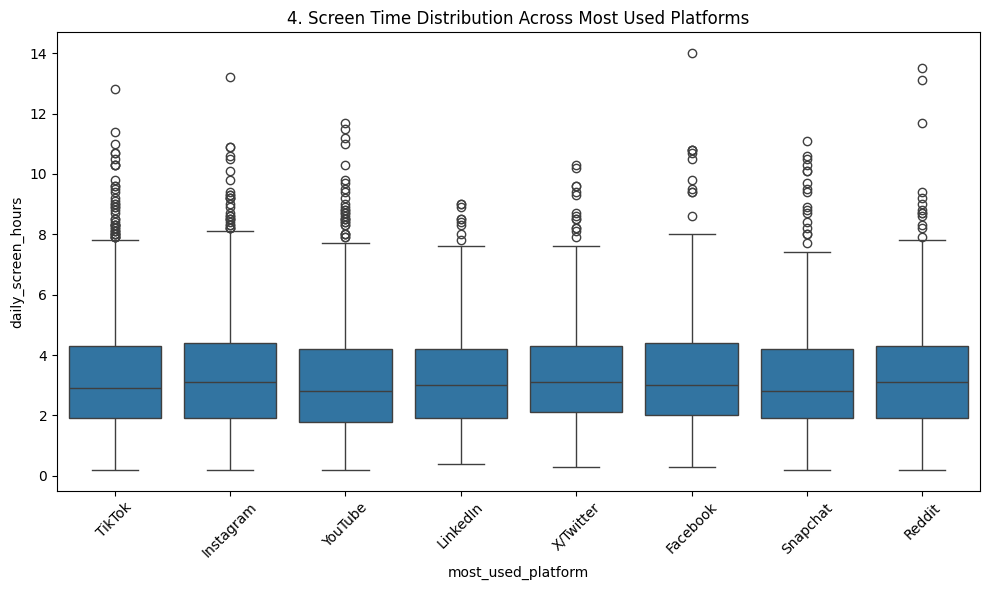

In [17]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='most_used_platform', y='daily_screen_hours')
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Screen Time Distribution Across Most Used Platforms')
show_fig()
plot_no += 1

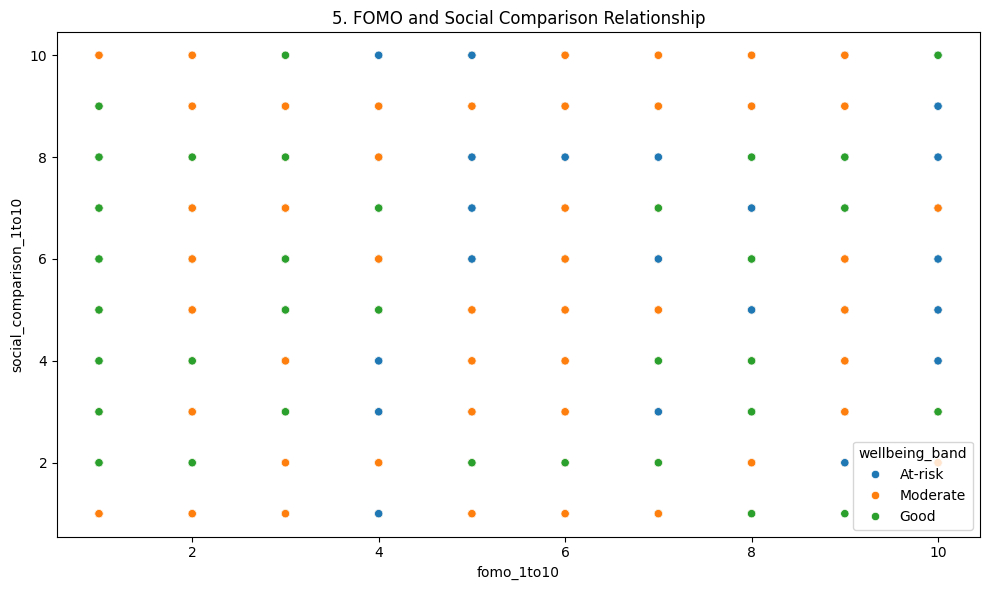

In [18]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='fomo_1to10', y='social_comparison_1to10', hue='wellbeing_band')
plt.title(f'{plot_no}. FOMO and Social Comparison Relationship')
show_fig()
plot_no += 1

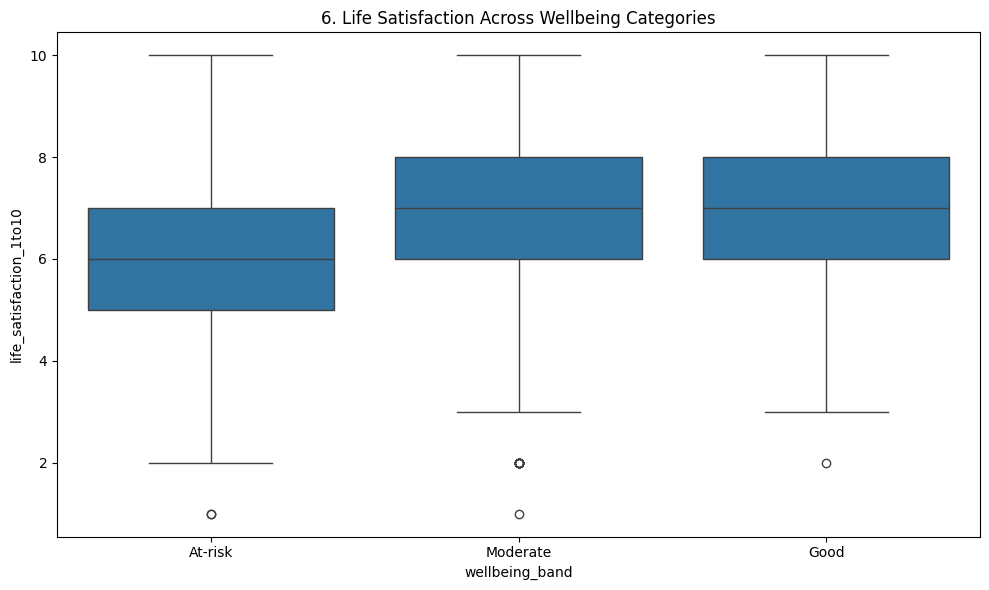

In [19]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='wellbeing_band', y='life_satisfaction_1to10')
plt.title(f'{plot_no}. Life Satisfaction Across Wellbeing Categories')
show_fig()
plot_no += 1

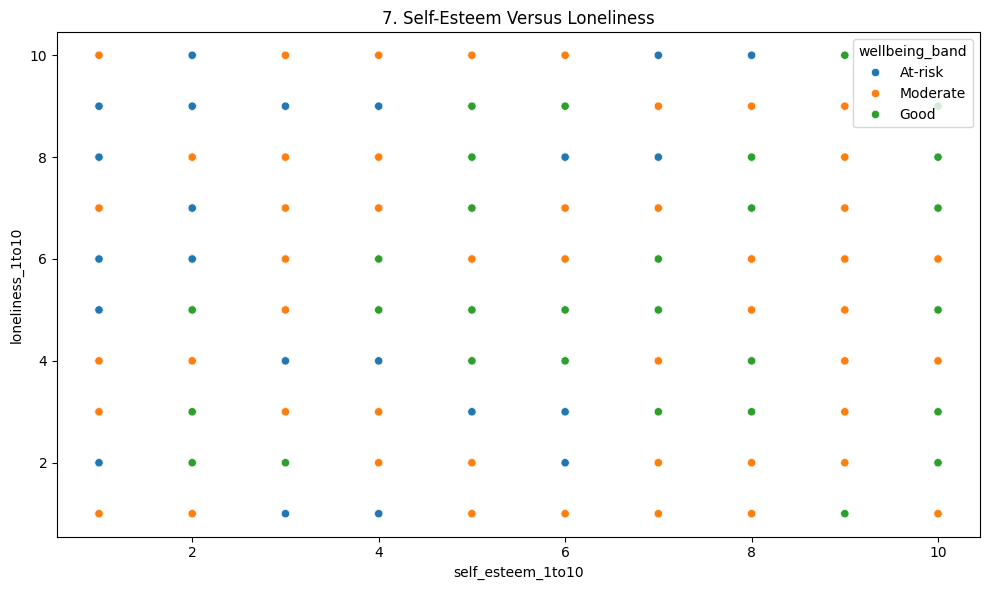

In [20]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='self_esteem_1to10', y='loneliness_1to10', hue='wellbeing_band')
plt.title(f'{plot_no}. Self-Esteem Versus Loneliness')
show_fig()
plot_no += 1

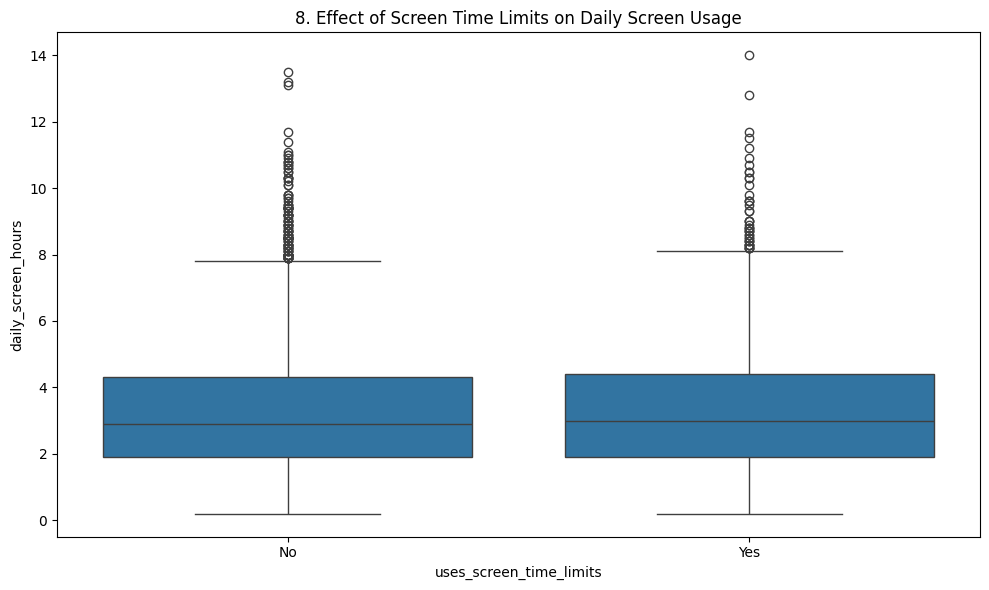

In [21]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='uses_screen_time_limits', y='daily_screen_hours')
plt.title(f'{plot_no}. Effect of Screen Time Limits on Daily Screen Usage')
show_fig()
plot_no += 1

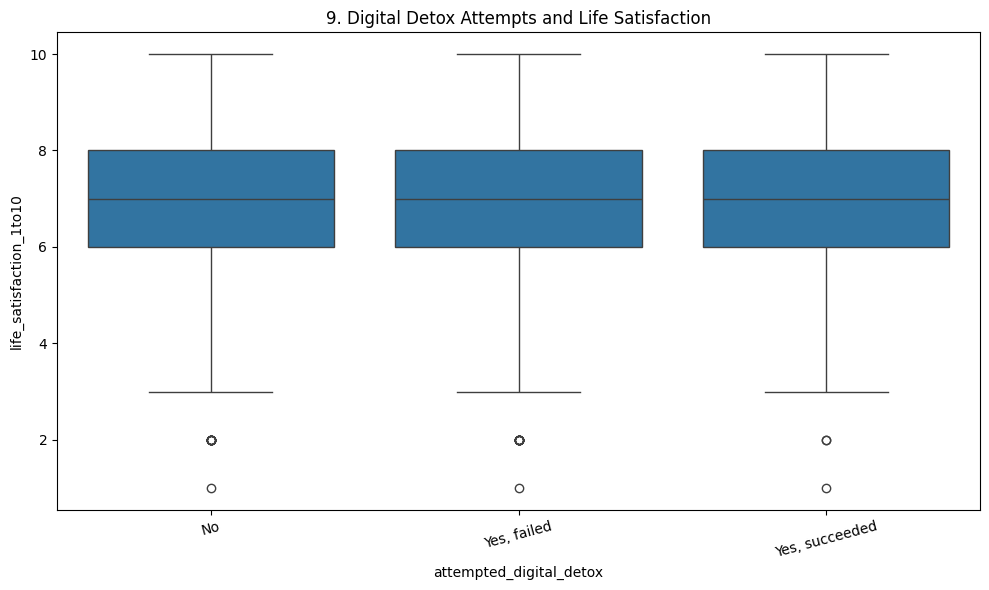

In [22]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='attempted_digital_detox', y='life_satisfaction_1to10')
plt.xticks(rotation=15)
plt.title(f'{plot_no}. Digital Detox Attempts and Life Satisfaction')
show_fig()
plot_no += 1

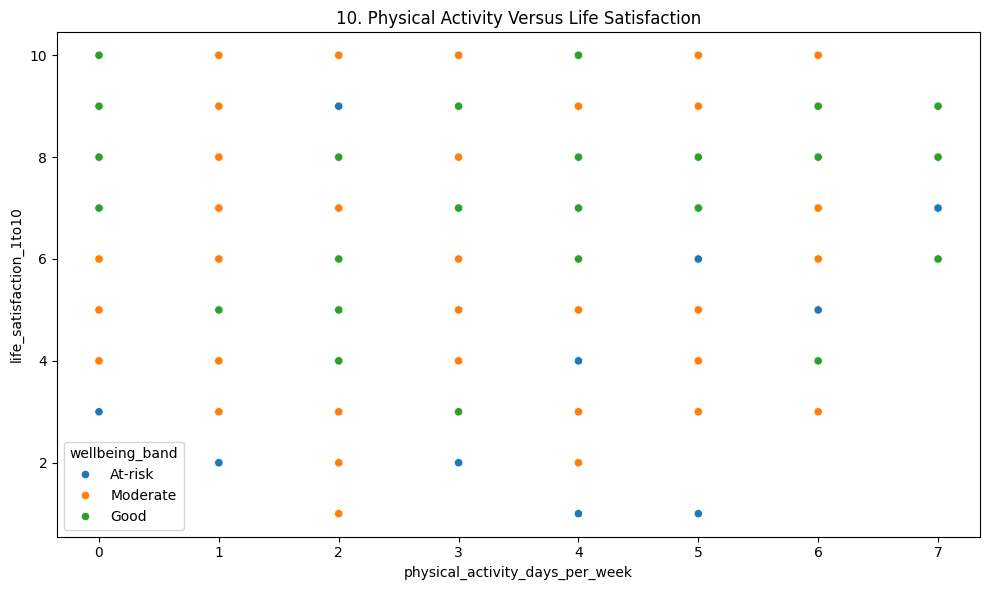

In [23]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='physical_activity_days_per_week', y='life_satisfaction_1to10', hue='wellbeing_band')
plt.title(f'{plot_no}. Physical Activity Versus Life Satisfaction')
show_fig()
plot_no += 1

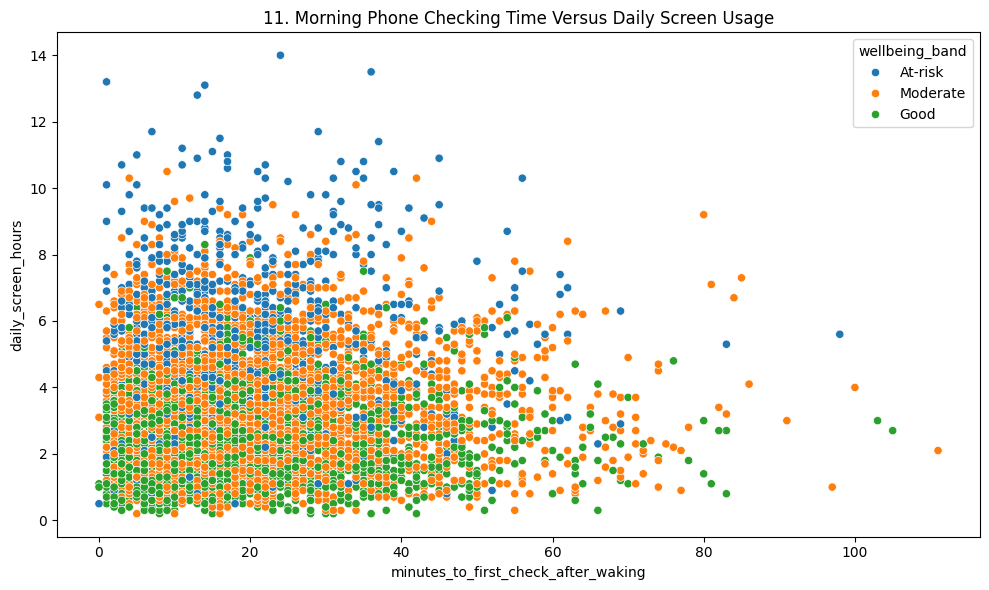

In [24]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='minutes_to_first_check_after_waking', y='daily_screen_hours', hue='wellbeing_band')
plt.title(f'{plot_no}. Morning Phone Checking Time Versus Daily Screen Usage')
show_fig()
plot_no += 1

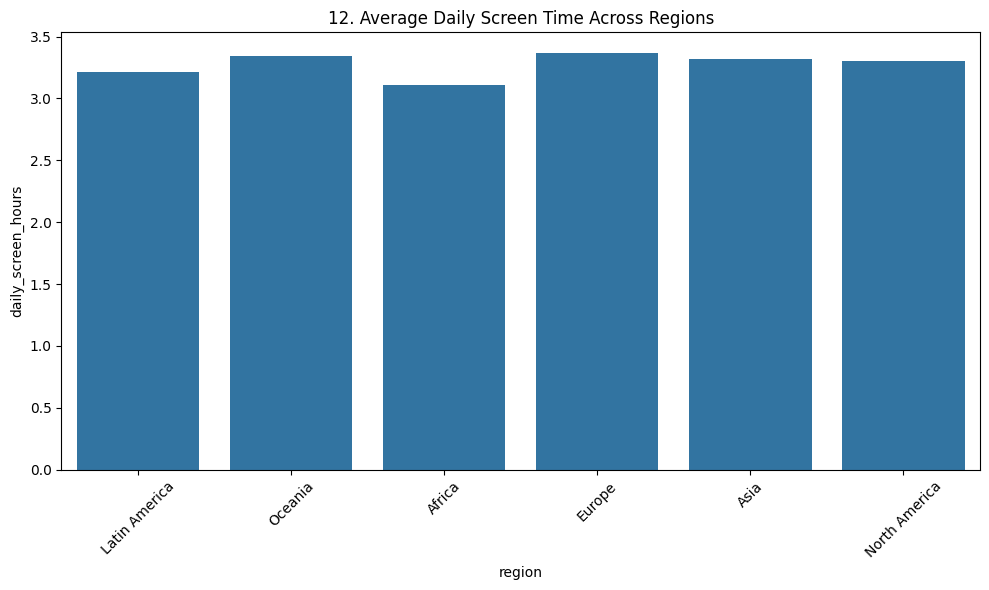

In [25]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='region', y='daily_screen_hours', estimator='mean', errorbar=None)
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Average Daily Screen Time Across Regions')
show_fig()
plot_no += 1

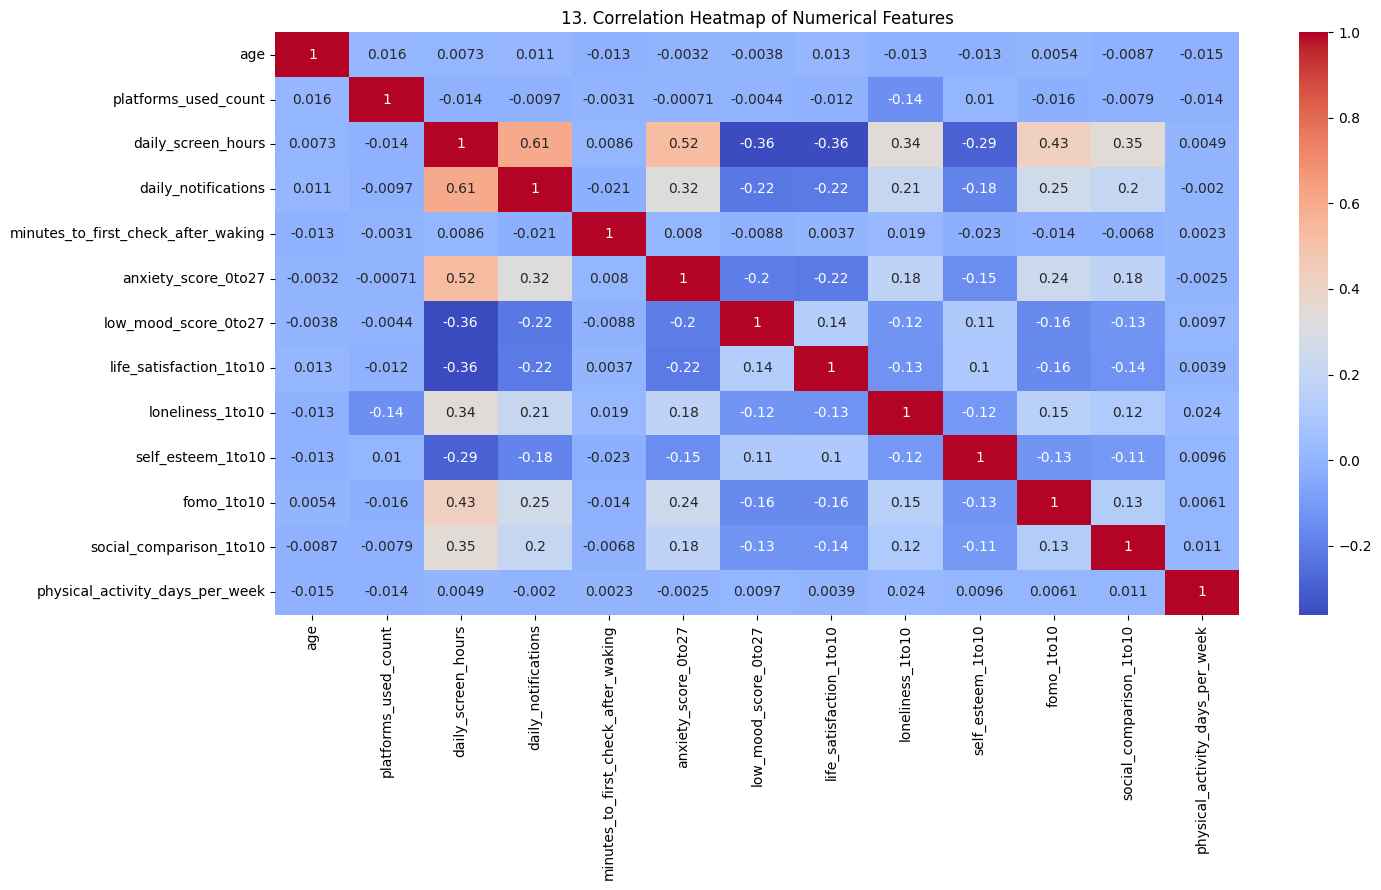

In [26]:
fig = plt.figure(figsize=(15, 9))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title(f'{plot_no}. Correlation Heatmap of Numerical Features')
show_fig()
plot_no += 1

# Model Training

## Separate features and target

In [27]:
X = df.drop(columns=['participant_id', 'wellbeing_band'])
y = df['wellbeing_band']

## Identify categorical and numerical columns

In [28]:
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(exclude=['object']).columns

## Create preprocessing pipeline

In [29]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

## Create SVM classification pipeline

In [30]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SVC(kernel='rbf', random_state=42))
])

## Split dataset into training and testing sets

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Train the model

In [32]:
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Make predictions

In [33]:
y_pred = model.predict(X_test)

## Calculate and print accuracy

In [34]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy*100:.0f}%")

Accuracy Score: 94%


## Display confusion matrix

<Figure size 800x600 with 0 Axes>

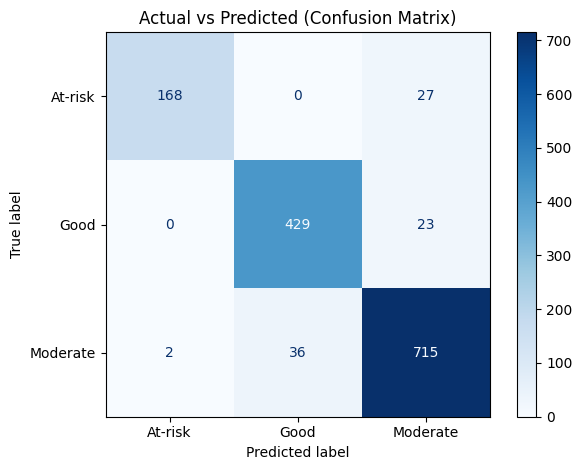

In [35]:
fig = plt.figure(figsize=(8,6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
plt.title('Actual vs Predicted (Confusion Matrix)')
plt.tight_layout()
plt.show()